In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shrutiy07/gravitationalwavesdataset/gw_dataset.h5
/kaggle/input/datasets/shrutiy07/gravitaionalwavesmetadata/metadata.csv


In [2]:
!pip install pycbc gwpy h5py pandas matplotlib tqdm scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 88.3 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Su

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import h5py

import pycbc
import gwpy
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
warnings.filterwarnings("ignore")

/usr/lib/python3.12/importlib/__init__.py:90: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)


BASIC INFO
Dataset attributes:
   detector: H1
   duration: 1.0
   generated_at: 2026-09-22 18:23:08
   n_samples: 4096
   sample_rate: 4096
   whitened: False

train: 3920 examples  ->  GW=2800, noise-only=1120
val: 840 examples  ->  GW=600, noise-only=240
test: 840 examples  ->  GW=600, noise-only=240

CLASS BALANCE


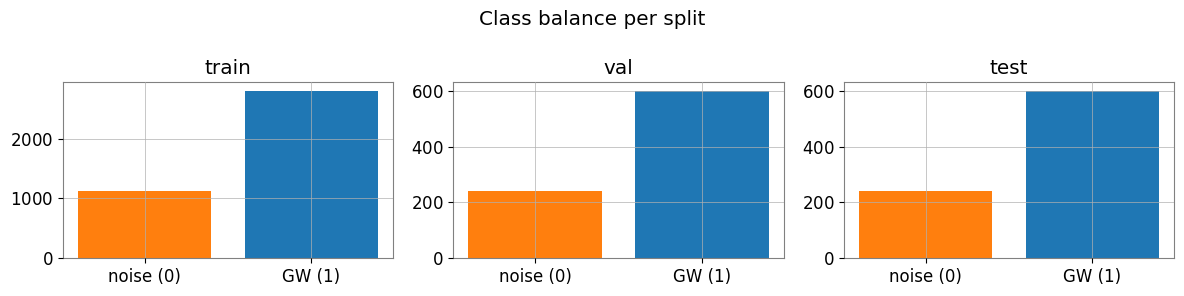


SNR DISTRIBUTION


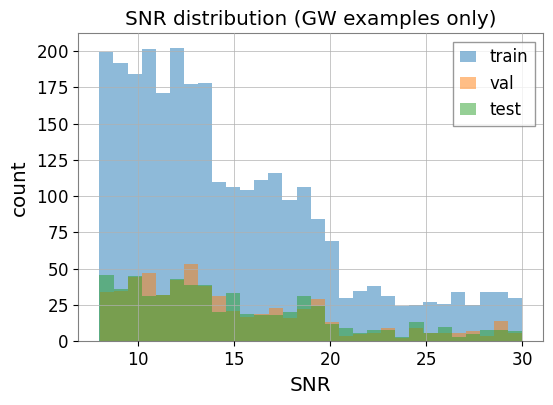


EXAMPLE SIGNALS (train split)


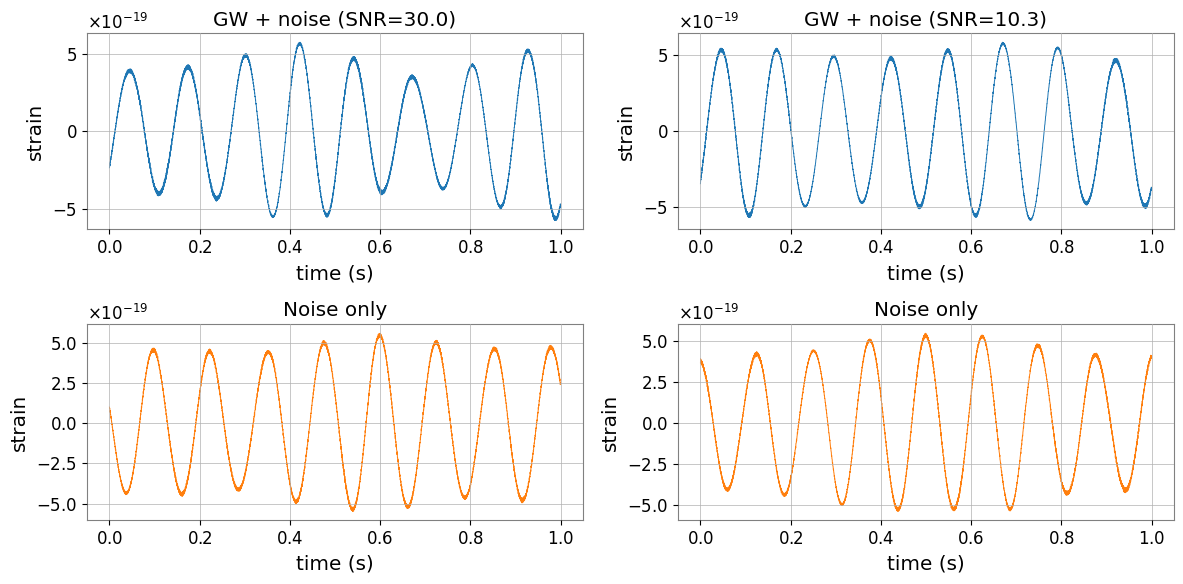


METADATA SUMMARY
metadata.csv shape: (5600, 13)
        sample_id  label template_id     noise_segment_id  split        snr  \
0  train_1_000000      1     tpl_078  H1_train_1238957773  train  29.950094   
1  train_1_000001      1     tpl_078  H1_train_1238956901  train  10.308101   
2  train_1_000002      1     tpl_078  H1_train_1238958936  train   9.724838   
3  train_1_000003      1     tpl_078  H1_train_1238956656  train  12.584456   
4  train_1_000004      1     tpl_078  H1_train_1238959285  train  20.325924   

       mass1      mass2  f_lower  peak_index detector  sample_rate  duration  
0  56.268245  35.467858    120.0        1081       H1         4096       1.0  
1  56.268245  35.467858    120.0         471       H1         4096       1.0  
2  56.268245  35.467858    120.0         653       H1         4096       1.0  
3  56.268245  35.467858    120.0        1313       H1         4096       1.0  
4  56.268245  35.467858    120.0         976       H1         4096       1.0  

E

In [4]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
 
def load_split(h5_path, split):
    """Load one split ('train', 'val', or 'test') as numpy arrays."""
    with h5py.File(h5_path, "r") as f:
        strain = f[split]["strain"][:]
        label = f[split]["label"][:]
        snr = f[split]["snr"][:]
    return strain, label, snr
 
 
def print_basic_info(h5_path):
    with h5py.File(h5_path, "r") as f:
        print("Dataset attributes:")
        for k, v in f.attrs.items():
            print(f"   {k}: {v}")
        print()
        for split in ["train", "val", "test"]:
            n = f[split]["strain"].shape[0]
            n_pos = int(np.sum(f[split]["label"][:] == 1))
            n_neg = int(np.sum(f[split]["label"][:] == 0))
            print(f"{split}: {n} examples  ->  GW={n_pos}, noise-only={n_neg}")
 
 
def plot_class_balance(h5_path):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    for ax, split in zip(axes, ["train", "val", "test"]):
        _, label, _ = load_split(h5_path, split)
        counts = [np.sum(label == 0), np.sum(label == 1)]
        ax.bar(["noise (0)", "GW (1)"], counts, color=["tab:orange", "tab:blue"])
        ax.set_title(split)
    fig.suptitle("Class balance per split")
    fig.tight_layout()
    plt.show()
 
 
def plot_snr_histogram(h5_path):
    fig, ax = plt.subplots(figsize=(6, 4))
    for split, color in zip(["train", "val", "test"], ["tab:blue", "tab:orange", "tab:green"]):
        _, label, snr = load_split(h5_path, split)
        ax.hist(snr[label == 1], bins=30, alpha=0.5, label=split, color=color)
    ax.set_xlabel("SNR")
    ax.set_ylabel("count")
    ax.set_title("SNR distribution (GW examples only)")
    ax.legend()
    plt.show()
 
 
def plot_example_signals(h5_path, split="train"):
    
    strain, label, snr = load_split(h5_path, split)
    pos_idx = np.where(label == 1)[0]
    neg_idx = np.where(label == 0)[0]
 
    fs = 4096  # samples per second
    t = np.arange(strain.shape[1]) / fs
 
    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    for k in range(2):
        i = pos_idx[k]
        axes[0, k].plot(t, strain[i], linewidth=0.7)
        axes[0, k].set_title(f"GW + noise (SNR={snr[i]:.1f})")
 
        j = neg_idx[k]
        axes[1, k].plot(t, strain[j], linewidth=0.7, color="tab:orange")
        axes[1, k].set_title("Noise only")
 
    for ax in axes.flat:
        ax.set_xlabel("time (s)")
        ax.set_ylabel("strain")
    fig.tight_layout()
    plt.show()
 
 
def print_metadata_summary(meta_path):
    df = pd.read_csv(meta_path)
    print("metadata.csv shape:", df.shape)
    print(df.head())
    print()
    print("Examples per split:")
    print(df["split"].value_counts())
    print()
    print("Examples per label:")
    print(df["label"].value_counts())
 
 
def run_eda(h5_path, meta_path):
    print("=" * 60)
    print("BASIC INFO")
    print("=" * 60)
    print_basic_info(h5_path)
 
    print()
    print("=" * 60)
    print("CLASS BALANCE")
    print("=" * 60)
    plot_class_balance(h5_path)
 
    print()
    print("=" * 60)
    print("SNR DISTRIBUTION")
    print("=" * 60)
    plot_snr_histogram(h5_path)
 
    print()
    print("=" * 60)
    print("EXAMPLE SIGNALS (train split)")
    print("=" * 60)
    plot_example_signals(h5_path, split="train")
 
    print()
    print("=" * 60)
    print("METADATA SUMMARY")
    print("=" * 60)
    print_metadata_summary(meta_path)
 
 
if __name__ == "__main__":
    H5_PATH = "/kaggle/input/datasets/shrutiy07/gravitationalwavesdataset/gw_dataset.h5"
    META_PATH = "/kaggle/input/datasets/shrutiy07/gravitaionalwavesmetadata/metadata.csv"
    run_eda(H5_PATH, META_PATH)

In [5]:
import h5py
import numpy as np
from scipy.signal import welch
from scipy.signal.windows import tukey
 
INPUT_H5 = "/kaggle/input/datasets/shrutiy07/gravitationalwavesdataset/gw_dataset.h5"          
OUTPUT_H5 = "/kaggle/working/gw_dataset_whitened.h5" 
FS = 4096
N_SAMPLES = 4096
TAPER_ALPHA = 0.2
N_NOISE_FOR_ASD = 40          #  TRAIN noise-only examples to use for the ASD
SPLITS = ["train", "val", "test"]
 
 
def estimate_shared_asd(h5_file, n_chunks=N_NOISE_FOR_ASD):
    
    labels = h5_file["train/label"][:]
    noise_idx = np.where(labels == 0)[0]
    n_chunks = min(n_chunks, len(noise_idx))
    chosen = noise_idx[:n_chunks]
 
    noise_chunks = [h5_file[f"train/strain"][i] for i in chosen]
    concatenated = np.concatenate(noise_chunks)
 
    freqs, psd = welch(concatenated, fs=FS, nperseg=FS, noverlap=FS // 2)
    asd = np.sqrt(psd)
    return freqs, asd
 
 
def whiten_one_sample(strain, freqs_asd, asd):
    tapered = strain * tukey(N_SAMPLES, alpha=TAPER_ALPHA)
 
    strain_fft = np.fft.rfft(tapered)
    fft_freqs = np.fft.rfftfreq(N_SAMPLES, d=1.0 / FS)
 
    asd_interp = np.interp(fft_freqs, freqs_asd, asd)
    asd_interp[asd_interp <= 0] = np.max(asd_interp) * 1e-3
 
    whitened_fft = strain_fft / asd_interp
    whitened = np.fft.irfft(whitened_fft, n=N_SAMPLES)
 
    whitened = whitened / np.std(whitened)
    return whitened
 
 
def main():
    with h5py.File(INPUT_H5, "r") as f_in, h5py.File(OUTPUT_H5, "w") as f_out:
 
        
        freqs_asd, asd = estimate_shared_asd(f_in)
 
        for split in SPLITS:
            print(f"Whitening split: {split} ")
 
            n_examples = f_in[f"{split}/strain"].shape[0]
            group_out = f_out.create_group(split)
 
            whitened_strain = np.zeros((n_examples, N_SAMPLES), dtype=np.float32)
            for i in range(n_examples):
                raw_strain = f_in[f"{split}/strain"][i]
                whitened_strain[i] = whiten_one_sample(raw_strain, freqs_asd, asd)
 
            group_out.create_dataset("strain", data=whitened_strain, compression="gzip")
 
            for key in f_in[split].keys():
                if key == "strain":
                    continue
                group_out.create_dataset(key, data=f_in[f"{split}/{key}"][:])
 
            print(f"  Done: {n_examples} examples whitened.")
 
        for attr_name, attr_value in f_in.attrs.items():
            f_out.attrs[attr_name] = attr_value
 
    print(f"\nSaved: {OUTPUT_H5}")
 
 
if __name__ == "__main__":
   main()

Whitening split: train 
  Done: 3920 examples whitened.
Whitening split: val 
  Done: 840 examples whitened.
Whitening split: test 
  Done: 840 examples whitened.

Saved: /kaggle/working/gw_dataset_whitened.h5


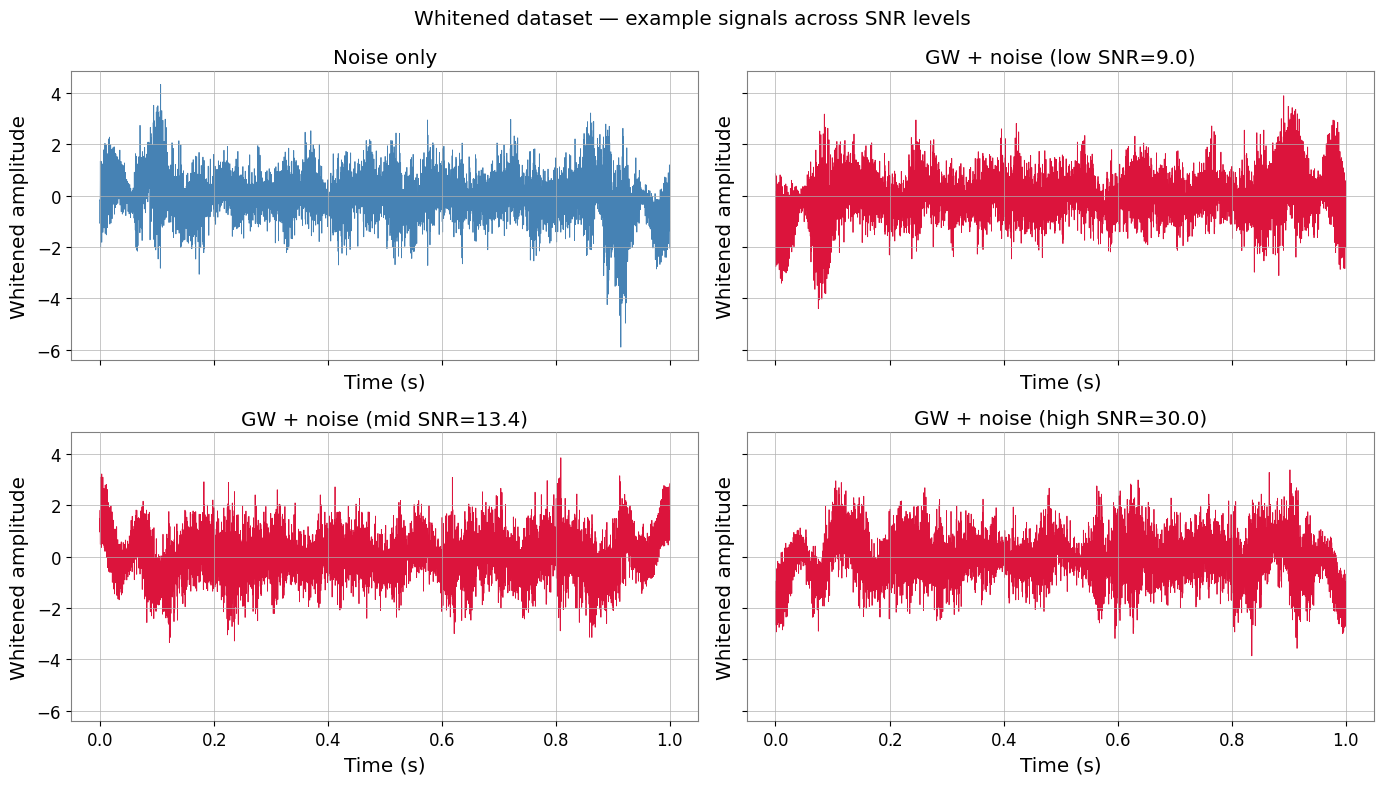

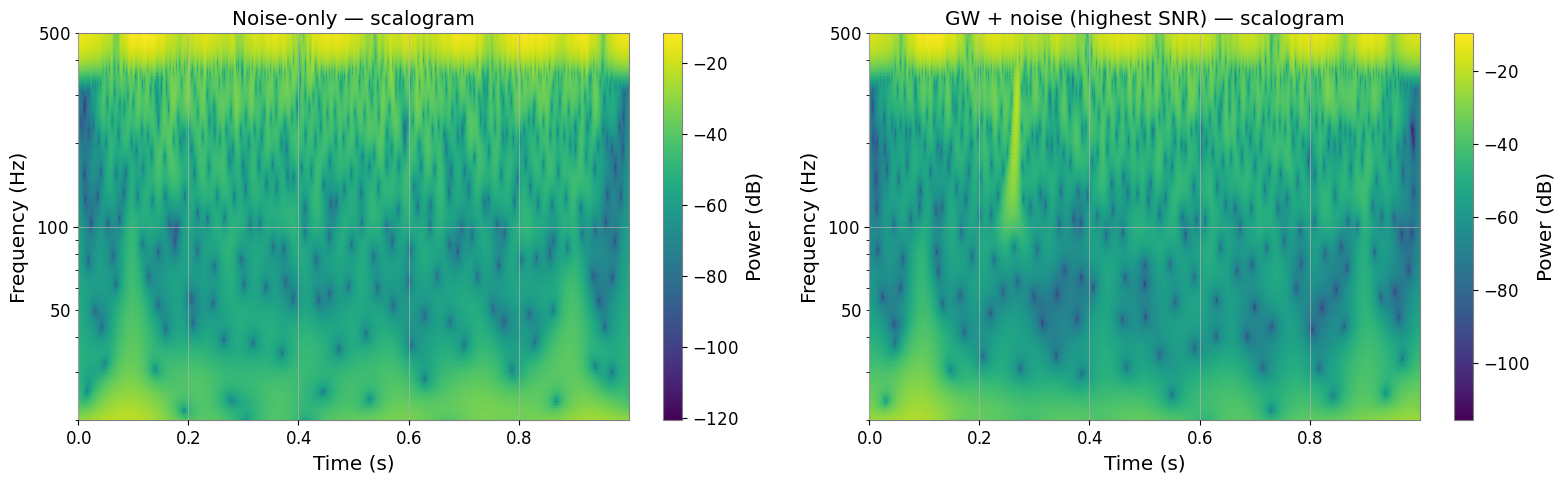

Saved: whitened_dataset_examples.png, whitened_dataset_scalogram.png


In [6]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
 
INPUT_H5 = "/kaggle/working/gw_dataset_whitened.h5"
SPLIT = "train"
FS = 4096
 
 
def cwt_scalogram(x, fs, f_min=20.0, f_max=500.0, n_freqs=120, w=6.0):
    n = len(x)
    freqs = np.geomspace(f_min, f_max, n_freqs)
    x_fft = np.fft.fft(x)
    fft_freqs = np.fft.fftfreq(n, d=1.0 / fs)
 
    power = np.zeros((n_freqs, n))
    for i, f0 in enumerate(freqs):
        s = w / (2 * np.pi * f0)
        psi_hat = (np.pi ** -0.25) * np.exp(-0.5 * (s * 2 * np.pi * fft_freqs - w) ** 2)
        conv = np.fft.ifft(x_fft * psi_hat)
        power[i] = np.abs(conv) ** 2
    return freqs, power
 
 
def main():
    with h5py.File(INPUT_H5, "r") as f:
        labels = f[f"{SPLIT}/label"][:]
        snrs = f[f"{SPLIT}/snr"][:]
 
        noise_indices = np.where(labels == 0)[0]
        signal_indices = np.where(labels == 1)[0]
 
        
        order = np.argsort(snrs[signal_indices])
        sorted_signal_idx = signal_indices[order]
        low_snr_idx = sorted_signal_idx[len(sorted_signal_idx) // 10]        # low end
        mid_snr_idx = sorted_signal_idx[len(sorted_signal_idx) // 2]         # middle
        high_snr_idx = sorted_signal_idx[-1]                                 # highest SNR
        noise_idx = noise_indices[0]
 
        picks = [
            ("Noise only", noise_idx, None),
            (f"GW + noise (low SNR={snrs[low_snr_idx]:.1f})", low_snr_idx, snrs[low_snr_idx]),
            (f"GW + noise (mid SNR={snrs[mid_snr_idx]:.1f})", mid_snr_idx, snrs[mid_snr_idx]),
            (f"GW + noise (high SNR={snrs[high_snr_idx]:.1f})", high_snr_idx, snrs[high_snr_idx]),
        ]
 
        strains = {label: f[f"{SPLIT}/strain"][idx] for label, idx, _ in picks}
 
    time = np.arange(FS) / FS
 
    # --- 1. Time-domain grid ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
    for ax, (label, idx, snr) in zip(axes.flat, picks):
        color = "steelblue" if snr is None else "crimson"
        ax.plot(time, strains[label], linewidth=0.6, color=color)
        ax.set_title(label)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Whitened amplitude")
    plt.suptitle("Whitened dataset — example signals across SNR levels")
    plt.tight_layout()
    plt.savefig("whitened_dataset_examples.png", dpi=150)
    plt.show()
 
    # --- 2. Scalogram: noise-only vs highest-SNR GW+noise ---
    noise_label = picks[0][0]
    high_label = picks[3][0]
 
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    for a, label, title in [
        (ax[0], noise_label, "Noise-only — scalogram"),
        (ax[1], high_label, "GW + noise (highest SNR) — scalogram"),
    ]:
        freqs, power = cwt_scalogram(strains[label], FS)
        mesh = a.pcolormesh(time, freqs, 10 * np.log10(power + 1e-20), shading="gouraud")
        a.set_yscale("log")
        a.set_ylim(freqs.min(), freqs.max())
        a.set_xlabel("Time (s)")
        a.set_ylabel("Frequency (Hz)")
        a.set_title(title)
        fig.colorbar(mesh, ax=a, label="Power (dB)")
    plt.tight_layout()
    plt.savefig("whitened_dataset_scalogram.png", dpi=150)
    plt.show()
 
    print("Saved: whitened_dataset_examples.png, whitened_dataset_scalogram.png")
 
 
if __name__ == "__main__":
    main()

In [7]:
import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader,WeightedRandomSampler
from sklearn.metrics import (roc_auc_score,f1_score,precision_score,
    recall_score,
    accuracy_score,confusion_matrix)
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 1. Load data (shuffled WITHIN each split, splits kept separate)

 
def load_split_shuffled(h5_path, split, seed=42):
    """Load one split and shuffle GW/noise examples within it."""
    with h5py.File(h5_path, "r") as f:
        strain = f[split]["strain"][:]
        label = f[split]["label"][:]
 
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(strain))
    return strain[idx].astype(np.float32), label[idx].astype(np.int64)

 
class GWDataset(Dataset):
    
 
    def __init__(self, strain, label):
        # shape (N, 4096) -> (N, 1, 4096): 1 input channel for Conv1d
        self.strain = torch.from_numpy(strain).unsqueeze(1)
        self.label = torch.from_numpy(label)
 
    def __len__(self):
        return len(self.label)
 
    def __getitem__(self, i):
        return self.strain[i], self.label[i]
 
 

#  Model

class GWCNN(nn.Module):
    def __init__(self, dropout=0.2):  
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=16, padding=7)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(kernel_size=4)
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=8, padding=3)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(kernel_size=4)
        self.drop2 = nn.Dropout(dropout)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=4, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(kernel_size=4)
        self.drop3 = nn.Dropout(dropout)

        self.relu = nn.ReLU()   
        self.flatten = nn.Flatten()

        
        self.fc1 = nn.Linear(128*63, 64)
        self.bn_fc1 = nn.BatchNorm1d(64)
        self.drop_fc1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 2)

    def _forward_conv(self, x):
        x = self.drop1(self.pool1(self.relu(self.bn1(self.conv1(x)))))
        x = self.drop2(self.pool2(self.relu(self.bn2(self.conv2(x)))))
        x = self.drop3(self.pool3(self.relu(self.bn3(self.conv3(x)))))         
        return self.flatten(x)   

    def forward(self, x):
        x = self._forward_conv(x)
        x = self.relu(self.bn_fc1(self.fc1(x)))
        x = self.drop_fc1(x)
        return self.fc2(x)
        
def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip=1.0):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
 
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)  
        optimizer.step()
 
        total_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)
 
    return total_loss / total, correct / total

def evaluate_with_metrics(model, loader, criterion, device):
    model.eval()
    all_probs = []
    all_labels = []
    total_loss = 0.0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            total_loss += loss.item() * x.size(0)
            total += x.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_probs.append(probs.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    # Classification threshold
    predictions = (all_probs >= 0.5).astype(int)
    auc = roc_auc_score(all_labels, all_probs)
    f1 = f1_score(all_labels,predictions,
        zero_division=0)
    precision = precision_score(all_labels, predictions,zero_division=0)

    recall = recall_score(all_labels,predictions,zero_division=0)

    accuracy = accuracy_score( all_labels,predictions)
    cm = confusion_matrix(all_labels,predictions)

    return (
        total_loss / total,auc,f1,precision,recall,accuracy,cm)
 


def run_training(h5_path, n_epochs=80, batch_size=64, lr=1e-3,weight_decay=0.0, patience_limit=20, min_epochs=25):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    X_train, y_train = load_split_shuffled(h5_path, "train")
    X_val, y_val = load_split_shuffled(h5_path, "val")
    X_test, y_test = load_split_shuffled(h5_path, "test")

    train_ds = GWDataset(X_train, y_train)
    val_ds = GWDataset(X_val, y_val)
    test_ds = GWDataset(X_test, y_test)

    class_counts = np.bincount(y_train)
    print("Class counts (train):", class_counts)
    sample_weights = (1.0 / class_counts)[y_train]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(y_train), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    first_x, first_y = next(iter(train_loader))
    print("Class distribution in first batch:", torch.bincount(first_y))
    model = GWCNN(dropout=0.2).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay) 
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=6)

    best_auc = 0.0
    patience_counter = 0   #early stopping

    for epoch in range(1, n_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        (val_loss,val_auc,val_f1,val_precision,val_recall,val_accuracy,val_cm) = evaluate_with_metrics(model,val_loader,criterion,device)
        scheduler.step(val_auc)

        if val_auc > best_auc:
            best_auc = val_auc
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            patience_counter += 1

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:3d}/{n_epochs} | " f"train_loss={train_loss:.4f} " f"train_acc={train_acc:.3f} | "
    f"val_loss={val_loss:.4f} " f"val_auc={val_auc:.3f} " f"val_f1={val_f1:.3f} "f"val_precision={val_precision:.3f} "
    f"val_recall={val_recall:.3f} "f"val_acc={val_accuracy:.3f} | "f"lr={current_lr:.2e}")

        if patience_counter >= patience_limit:  
            print(f"Early stopping at epoch {epoch} (no val_auc improvement for {patience_limit} epochs)")
            break

    model.load_state_dict(torch.load("best_model.pt"))
    (test_loss,test_auc,test_f1,test_precision,test_recall,test_accuracy,test_cm) = evaluate_with_metrics(model,test_loader,criterion,device)
    print(f"\nBest val_auc during training: {best_auc:.3f}")
    print(f"Final test results (best checkpoint) | "f"test_loss={test_loss:.4f} "f"test_auc={test_auc:.3f} "
    f"test_f1={test_f1:.3f} "f"test_precision={test_precision:.3f} " f"test_recall={test_recall:.3f} "f"test_accuracy={test_accuracy:.3f}")

    print("\nTest confusion matrix:")
    print(test_cm)
    return model

if __name__ == "__main__":
    
    H5_PATH = "/kaggle/working/gw_dataset_whitened.h5"
    run_training(H5_PATH, n_epochs=80, batch_size=64, lr=1e-3,weight_decay=0.0,patience_limit=20,min_epochs=25)

Using device: cuda
Class counts (train): [1120 2800]
Class distribution in first batch: tensor([25, 39])
Epoch   1/80 | train_loss=0.7232 train_acc=0.516 | val_loss=0.7181 val_auc=0.550 val_f1=0.355 val_precision=0.760 val_recall=0.232 val_acc=0.399 | lr=1.00e-03
Epoch   2/80 | train_loss=0.6996 train_acc=0.522 | val_loss=0.6822 val_auc=0.497 val_f1=0.688 val_precision=0.710 val_recall=0.667 val_acc=0.568 | lr=1.00e-03
Epoch   3/80 | train_loss=0.6950 train_acc=0.518 | val_loss=0.6838 val_auc=0.512 val_f1=0.701 val_precision=0.732 val_recall=0.673 val_acc=0.590 | lr=1.00e-03
Epoch   4/80 | train_loss=0.6943 train_acc=0.532 | val_loss=0.6662 val_auc=0.494 val_f1=0.754 val_precision=0.723 val_recall=0.788 val_acc=0.633 | lr=1.00e-03
Epoch   5/80 | train_loss=0.6878 train_acc=0.550 | val_loss=0.6694 val_auc=0.504 val_f1=0.754 val_precision=0.728 val_recall=0.782 val_acc=0.636 | lr=1.00e-03
Epoch   6/80 | train_loss=0.6871 train_acc=0.547 | val_loss=0.6712 val_auc=0.488 val_f1=0.732 val_pr

In [8]:
def load_split_shuffled(h5_path, split, seed=42):
    
    with h5py.File(h5_path, "r") as f:
        strain = f[split]["strain"][:]
        label = f[split]["label"][:]
 
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(strain))
    return strain[idx].astype(np.float32), label[idx].astype(np.int64)
 
 
class GWDataset(Dataset):
   
 
    def __init__(self, strain, label):
        # shape (N, 4096) -> (N, 1, 4096): 1 input channel for Conv1d
        self.strain = torch.from_numpy(strain).unsqueeze(1)
        self.label = torch.from_numpy(label)
 
    def __len__(self):
        return len(self.label)
 
    def __getitem__(self, i):
        return self.strain[i], self.label[i]
 
 

class GWCNNSimple(nn.Module):
    def __init__(self):
        super().__init__()
 
        
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=16, padding=7)
        self.pool1 = nn.MaxPool1d(kernel_size=4)
 
       
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=8, padding=3)
        self.pool2 = nn.MaxPool1d(kernel_size=4)
 
       
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=4, padding=1)
        self.pool3 = nn.MaxPool1d(kernel_size=4)
 
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
 
        
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 4096)
            dummy_out = self._forward_conv(dummy)
            flat_size = dummy_out.shape[1]
 
        
        self.fc1 = nn.Linear(flat_size, 64)
        self.fc2 = nn.Linear(64, 2)  #
 
    def _forward_conv(self, x):
        # order: Conv -> Pool -> ReLU
        x = self.relu(self.pool1(self.conv1(x)))
        x = self.relu(self.pool2(self.conv2(x)))
        x = self.relu(self.pool3(self.conv3(x)))
        return self.flatten(x)
 
    def forward(self, x):
        
        x = self._forward_conv(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)  
        return x
 

#  Training / evaluation loops
 
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
 
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
 
        total_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)
 
    return total_loss / total, correct / total
 
 
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
 
            total_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += x.size(0)
 
    return total_loss / total, correct / total
 
 

 
def run_training_simple(h5_path, n_epochs=15, batch_size=32, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
 
    X_train, y_train = load_split_shuffled(h5_path, "train")
    X_val, y_val = load_split_shuffled(h5_path, "val")
    X_test, y_test = load_split_shuffled(h5_path, "test")
 
    train_ds = GWDataset(X_train, y_train)
    val_ds = GWDataset(X_val, y_val)
    test_ds = GWDataset(X_test, y_test)
 
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
 
    # model, loss, optimizer
    model = GWCNNSimple().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
 
    # training loop
    for epoch in range(1, n_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        print(f"Epoch {epoch:2d}/{n_epochs} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}")
 
    # final test evaluation 
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"\nFinal test results | test_loss={test_loss:.4f} test_acc={test_acc:.3f}")
 
 
if __name__ == "__main__":
    H5_PATH = "/kaggle/working/gw_dataset_whitened.h5"
    run_training_simple(H5_PATH, n_epochs=15, batch_size=32, lr=1e-3)

Using device: cuda
Epoch  1/15 | train_loss=0.6134 train_acc=0.714 | val_loss=0.6148 val_acc=0.714
Epoch  2/15 | train_loss=0.6028 train_acc=0.714 | val_loss=0.5991 val_acc=0.714
Epoch  3/15 | train_loss=0.6004 train_acc=0.714 | val_loss=0.5988 val_acc=0.714
Epoch  4/15 | train_loss=0.6009 train_acc=0.714 | val_loss=0.5983 val_acc=0.714
Epoch  5/15 | train_loss=0.6006 train_acc=0.714 | val_loss=0.5983 val_acc=0.714
Epoch  6/15 | train_loss=0.6000 train_acc=0.714 | val_loss=0.6028 val_acc=0.714
Epoch  7/15 | train_loss=0.6006 train_acc=0.714 | val_loss=0.5983 val_acc=0.714
Epoch  8/15 | train_loss=0.5989 train_acc=0.714 | val_loss=0.5984 val_acc=0.714
Epoch  9/15 | train_loss=0.5993 train_acc=0.714 | val_loss=0.5985 val_acc=0.714
Epoch 10/15 | train_loss=0.6009 train_acc=0.714 | val_loss=0.5985 val_acc=0.714
Epoch 11/15 | train_loss=0.5997 train_acc=0.714 | val_loss=0.5990 val_acc=0.714
Epoch 12/15 | train_loss=0.5995 train_acc=0.714 | val_loss=0.5984 val_acc=0.714
Epoch 13/15 | train_l